In [3]:
import pandas as pd
import numpy as np

df_baseball = pd.read_csv('baseball.csv')
df_na_salary = df_baseball[df_baseball['Salary'].isna()] # игроки без зарплат
#  Переменная Salary (и log Salary) может содержать пропуски, 
#произведите подстановку пропусков методом согласно вашему варианту. Пересчитайте 
#logSalary как log(1+Salary), чтобы получить более симметричное распределение.

print(df_na_salary.shape[0]) # наблюдений с отсутвующим зн-ем.

# По моему варианту, KNNImputer.
#KNNImputer - метод не строит никаких кластеров, просто из генеарльной выборки находит самые близкие наблюдения к нашему наблюдению(например 5 соседей),
#значит k=5. Таких соседей мы находим с наименьшими расстояними, расстояния считаются по евклидовой формуле, манхэттенское, минковское.
#Как только нходим соседей, по ним уже заполняем пропуски, причем признаки с пропусками в расчете расстояния игнорируются.
#Ну и уже в зависимости от типа признака (числовой показатель -> берем среднее по соседям) / (категориальный показатель -> берем моду).
#Также есть след. обработчики пропусков: SimpleImputer - простой метод. 
#class sklearn.impute.SimpleImputer(missing_values=nan, strategy='mean')
#Здесь missing_values=тип пропущенного значения, strategy = стратегия заполнения, принимает след значения ['mean','constant','most_frequent', 'median']
#За счет строгой привязки к данным, предположу что использование такого метода уместно при налиичии малого количества пропусков.
#MissingIndicator - метод возвращающий индикаторы, например матрицу с булевыми значениями о налиичии missing_values True или отсутствии False.
from sklearn.impute import KNNImputer

#Прежде чем выполнить заполнение пропусков, подгоним данные под нужный вид, категоризуем строки и имя сделаем DataFrame.Index
df_baseball.index = df_baseball['Name']
df_baseball.drop(['Name'], axis=1, inplace=True)

# print(df_baseball.head())

#Теперь строчные признаки заенкодим, следующие енкодеры:
#LabelEncoder() - принимает столбец, например можно закинуть столбец df
#OrdinalEncoder(categories) - принимает столбец, но в отличии от LabelEncoder, можно задать последовательность назначения признакам числового показателя.
#OneHotEncoder(categories, min_frequency) - как следует из названия, принимает колонку и создает столбцы, где количество различных значений признаков
#по столбцу == количеству новых столбцов со значениями 1/0 в зависимости он наличия изначального значения у наблюдения.
#также есть понятие min_frequency, задает минимальный порог встречаемости признака, дабы сократить разреженность.

# Сейчас проверим какие столбцы имеют тип для применения енкодера
print(df_baseball.dtypes.unique())
df_columns_object = df_baseball.select_dtypes(include=df_baseball.dtypes.unique()[0]).columns
print(df_columns_object) # Это те столбцы , которые нужно енкодить.
print(df_baseball[df_columns_object].nunique()) # Оценим сколько значений могут принимать признаки
# Поступим следующим образом, для признаков с невысокой вариативностью построим енкодер OneHot, для остальных LabelEncoder.
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le_Team = LabelEncoder().fit(df_baseball['Team'])
le_Team_ = le_Team.transform(df_baseball['Team'])
# print(le_Team.classes_)
# print(le_Team_)

le_Position = LabelEncoder().fit(df_baseball['Position'])
le_Position_ = le_Position.transform(df_baseball['Position'])
# print(le_Position.classes_)
# print(le_Position_)

ohe_League_Division = OneHotEncoder().fit(df_baseball[['League', 'Division']])
ohe_League_Division_ = ohe_League_Division.transform(df_baseball[['League', 'Division']]).toarray()
# print(ohe_League_Division.get_feature_names_out(['League', 'Division']))
# print(ohe_League_Division_)

ohe_div = OneHotEncoder(min_frequency = 4, handle_unknown='infrequent_if_exist').fit(df_baseball[['Div']])
ohe_div_ = ohe_div.transform(df_baseball[['Div']]).toarray()
# print(ohe_div.get_feature_names_out(['Div']))
# print(ohe_div_)

df_baseball_ = df_baseball.copy(deep=True)

df_baseball_.drop(columns=df_columns_object, inplace=True, axis=1)

df_baseball_.insert(len(df_baseball_.columns), 'Position', le_Position_)
df_baseball_.insert(len(df_baseball_.columns), 'Team', le_Team_)

df_baseball_[ohe_League_Division.get_feature_names_out(['League', 'Division'])] = ohe_League_Division_
df_baseball_[ohe_div.get_feature_names_out(['Div'])] = ohe_div_

# print(df_baseball_)

imputer_ = KNNImputer(n_neighbors=5, missing_values=np.nan).fit_transform(df_baseball_)
df_baseball_[df_baseball_.columns] = imputer_
df_baseball_['logSalary'] = np.log( 1 + df_baseball_['Salary'] )

# print(df_baseball_.isna().any().any() == False)

59
[dtype('O') dtype('int64') dtype('float64')]
Index(['Team', 'League', 'Division', 'Position', 'Div'], dtype='object')
Team        24
League       2
Division     2
Position    25
Div          4
dtype: int64


In [4]:
#Нормализация переменных – приведите числовые переменные к близким шкалам с помощью 
#методов для вашего варианта и закодируйте категориальные с помощью OneHotEncoder.
#Мой метод MaxAbsScaler
#Но бывают еще методы:
#StandardScaler(with_mean, with_std) - данный метод центрирует данные по формуле z = (x-u)/s, где u - среднее, s = стандартное отклонение. Может привести к отриц. зн-ям
#RobustScaler - метод нормализующий данные, при этом ложно не скрывает outliers(выбросы), z = (X - Xmedian)/(X75%-X25%).
#MinMaxScaler - метод сжимает данные в значения от 0 до 1, другими словами мы создаем расстояние в данных z = (X - Xmin)/(Xmax-Xmin).
#MaxAbsScaler - метод сжимает данные в значения от -1 до 1, за счет отношения каждого значения X к макс. по модулю z = X / |Xmax|.Центрируем 0 в данных.
#Normalizer(norm = 'L2' | 'L1') - метод работает с НАБЛЮДЕНИЯМИ раскладывает наблюдение в единичный вектор, L1-Манхэттенская, L2- Евклидова, и Z = X / ||X||.

In [5]:
from sklearn.preprocessing import maxabs_scale

def maxabs_scale_(Xfit, **kwargs):
    return maxabs_scale(Xfit, **kwargs) 
    
X_scale = maxabs_scale_(df_baseball_.to_numpy())
print(X_scale)


[[0.42649199 0.27731092 0.025      ... 0.         0.         0.        ]
 [0.45851528 0.34033613 0.175      ... 0.         0.         1.        ]
 [0.69723435 0.54621849 0.45       ... 1.         0.         0.        ]
 ...
 [0.69141194 0.52941176 0.075      ... 1.         0.         0.        ]
 [0.83406114 0.60504202 0.225      ... 0.         0.         0.        ]
 [0.91848617 0.71428571 0.225      ... 1.         0.         0.        ]]


In [6]:
# С помощью восходящей иерархической кластеризации с выбранными параметрами
#расстояния согласно вашему варианту постройте кластерную модель данных и дендрограмму
#для топ 20 кластеров.
# Мой вариант - link=average, dist=euclidean
# Иерархиечкая кластериазция делится на два типа, восходящая, нисходязщая - случай когда данные помещаются в один кластер, а затем
#разбиваются до 1 наблюдение = 1 кластеру, в нашем случпе восходящая - когда изначально даны n число кластеров, где n - кол-во наблюдений.
#Выбираются параметры тип дистанции: Евклидова или Манхэттенская, параметр link: способ расчета дистанции между кластерами с более чем 1 наблюдением,
#имеют следующие значения:
#ward - минимизирует дисперсию объединяемых кластеров.
#complete - использует максимальные расстояния между всеми наблюдениями из двух наборов данных.
#average - использует среднее значение расстояний каждого наблюдения из двух наборов данных.
#single - использует минимальное из расстояний между всеми наблюдениями двух наборов.

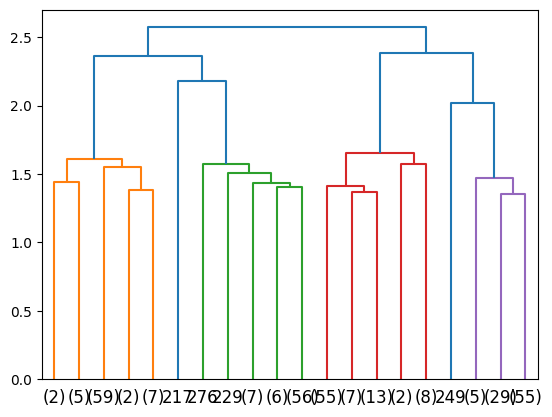

In [7]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from matplotlib import pyplot as plt

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

clustering = AgglomerativeClustering(n_clusters=None,distance_threshold=0,metric="euclidean",linkage="average").fit(X_scale) # Используем данные в np.array после скалирования
#n_clusters по дефолту равен 2, мы указываем None и distance_threshold=0 чтобы получить полное дерево.
#print(clustering.labels_)

plot_dendrogram(clustering,truncate_mode='lastp',p=20) # топ(truncate_mode='lastp') 20 кластеров(p=20).
plt.show()

#print(clustering.labels_)
# axis 0Y - расстояние между кластерами
# axis 0X - наблюдения

Наиболее подходящее количество кластеров для задачи = 4


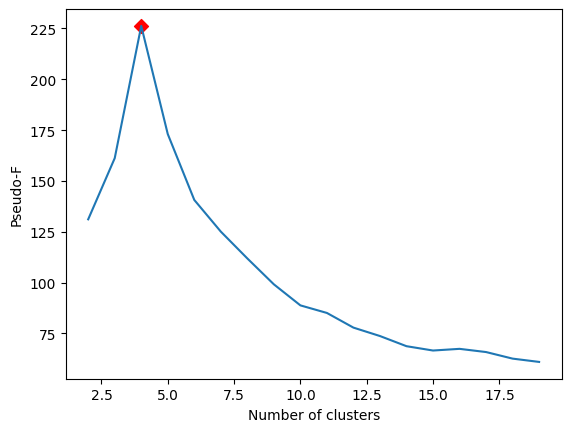

In [16]:
# Рассчитайте значение критерия pseudoF для вариантов кластеризации 2-20 кластеров,
# постройте график зависимости критерия от числа кластеров и выберите оптимальное (первый
# локальный пик критерия при обходе от малого числа кластеров к большому). Отметьте точку
# на графике. Сколько кластеров получилось?
# pseudoF = (TSS/(k-1))/(BSS/(n-k))
# TSS - total sum square
# BSS - between-clusters sum square
# В данном фрагменте представлен TSS - как дисперсия кластеров, а BSS - как дисперсия внутри кластеров. То есть:
# TSS = Q-W, BSS = W
#

def sum_dist_to_center(X):
    center = np.mean(X, axis=0)
    return ((X-center)**2).sum()
    
def choose_num_clusters(X, max_clust = 20,metric="euclidean"):
    N = X.shape[0]
    Q = sum_dist_to_center(X)
    pseudo_f = np.array([])
    for G in range(2, max_clust):
        clustering = AgglomerativeClustering(n_clusters = G, metric=metric,linkage="average").fit(X)
        W = 0
        for l in range(G):
            elems = X[clustering.labels_ == l]
            W += sum_dist_to_center(elems)
        fisher_stat = ((Q - W)/(G - 1))/ (W/(N - G))
        pseudo_f = np.append(pseudo_f, fisher_stat)
    plt.plot(range(2, max_clust), pseudo_f)
    ind_best_clust = np.argmax(pseudo_f)
    plt.scatter(ind_best_clust + 2, 
                pseudo_f[ind_best_clust], 
                color="r", marker="D", s=50)
    plt.xlabel("Number of clusters")
    plt.ylabel("Pseudo-F")
    return ind_best_clust + 2
    
k = choose_num_clusters(X_scale)
print(f'Наиболее подходящее количество кластеров для задачи = {k}')

[0 1 2 3]


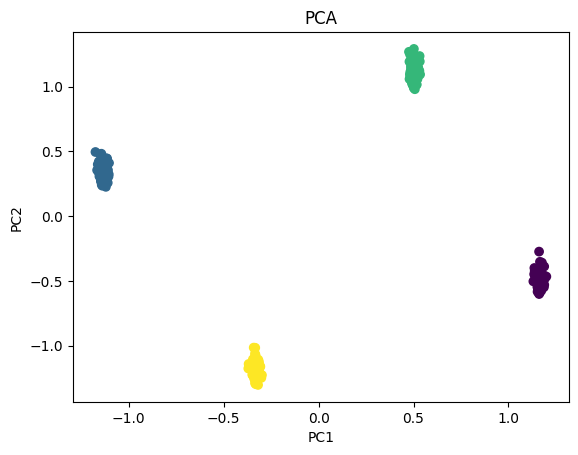

In [27]:
#С помощью метода проекции для вашего варианта постройте отображение на плоскость, 
#цветом точки укажите номер кластера
# my method - PCA
def AgglomerativeClustering_(Xfit, n_clusters=4, metric='euclidean', linkage="average", **kwargs):
    return AgglomerativeClustering(n_clusters=n_clusters, metric=metric, linkage=linkage, **kwargs).fit(Xfit)
    
clusters = AgglomerativeClustering_(X_scale, n_clusters=4, metric='euclidean', linkage="average")

print(np.unique(clusters.labels_)) # наши кластеры, будем закрашивать: 0 red, 1 blue, 2 green, 3 yellow.

from sklearn.decomposition import PCA
def PCA_(Xfit, n_components=2,**kwargs):
    return PCA(n_components=2,**kwargs).fit_transform(Xfit)
    
features = PCA_(X_scale, n_components=2)

plt.scatter(features[:,0], features[:,1], c=clusters.labels_)
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [28]:
#Выполните кластеризацию сферическими кластерами с прототипом методом из вашего
# варианта, также постройте проекцию как на шаге 6, определите наиболее типичного представителя (по имени) в каждом из кластеров.
# my method kmeans

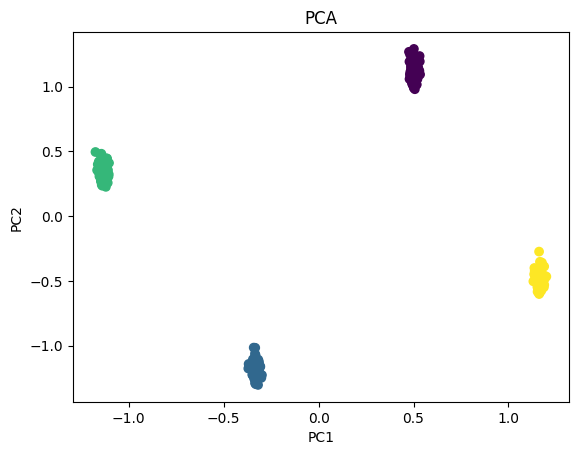

Hassey, Ron, 0 - cluster
Walling, Denny, 1 - cluster
Bush, Randy, 2 - cluster
Redus, Gary, 3 - cluster
Adjusted Rand Index: 1.000


In [30]:
from sklearn.cluster import KMeans

def KMeans_(Xfit, n_clusters=4, **kwargs):
    return KMeans(n_clusters=n_clusters, **kwargs).fit(Xfit)
kmeans_clusters = KMeans_(X_scale)

#print(kmeans_clusters.labels_) # кластеры
# print(kmeans_clusters.cluster_centers_) # типичные представители кластеров

plt.scatter(features[:,0], features[:,1], c=kmeans_clusters.labels_)
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

from sklearn.metrics.pairwise import pairwise_distances_argmin

def prototype_(centers, Xfit):
    return pairwise_distances_argmin(centers, Xfit)
    
rows_n = prototype_(kmeans_clusters.cluster_centers_, X_scale)

for r in rows_n:
    print(f'{df_baseball.iloc[r].name}, {kmeans_clusters.labels_[r]} - cluster')

Наиболее подходящее количество кластеров для задачи = 10


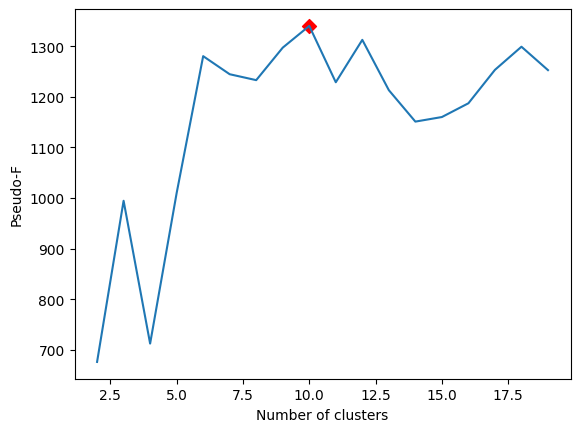

In [34]:
# Произведите дополнительную предобработку набора данных, сделав распределения
# переменных более симметричными. Для этого с помощью гисторамм или метода describe в
# dataframe или метода skew найдите переменные с одной модой и тяжелым правым хвостом,
# примените к ним преобразование log(1+x). Запустите функцию из шага 8. Как изменилось
# число кластеров, проекции и лучшие представители. Как считаете, субъективное качество
# кластеризации изменилось? Как и почему?

df_baseball_log = df_baseball_.copy(deep=True)
skew_ = df_baseball_log.skew()
skew_ = skew_[skew_>0.5]

for c in skew_.index:
    df_baseball_log[c] = np.log1p(df_baseball_log[c])

X_scale_new = df_baseball_log.to_numpy()
k_new = choose_num_clusters(X_scale_new)
print(f'Наиболее подходящее количество кластеров для задачи = {k_new}')

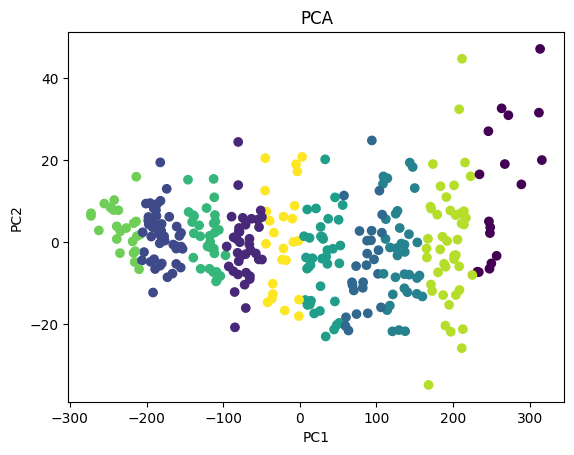

Bell, George, 0 - cluster
Ashby, Alan, 1 - cluster
Cerone, Rick, 2 - cluster
Diaz, Bo, 3 - cluster
Coles, Darnell, 4 - cluster
Hatcher, Billy, 5 - cluster
Roenicke, Ron, 6 - cluster
Reed, Jeff, 7 - cluster
Webster, Mitch, 8 - cluster
Scioscia, Mike, 9 - cluster


In [48]:
kmeans_clusters_new = KMeans_(X_scale_new, n_clusters=10)

features_new = PCA_(X_scale_new)
plt.scatter(features_new[:,0], features_new[:,1], c=kmeans_clusters_new.labels_)
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

rows_n_new = prototype_(kmeans_clusters_new.cluster_centers_, X_scale_new)

for r in rows_n_new:
    print(f'{df_baseball_log.iloc[r].name}, {kmeans_clusters_new.labels_[r]} - cluster')

# Как считаете, субъективное качество кластеризации изменилось? Как и почему?
# Кластеризация изменилась, данные стали ближе к друг другу, что в данном случае дает более правильную кластеризацию, без сильных расстояний
# спровоцированных большими значениями в некоторых признаках.

Наиболее значимые признаки = ['CrRbi' 'Div_NW' 'Team' 'nAssts' 'nOuts']
Наиболее подходящее количество кластеров для задачи = 3


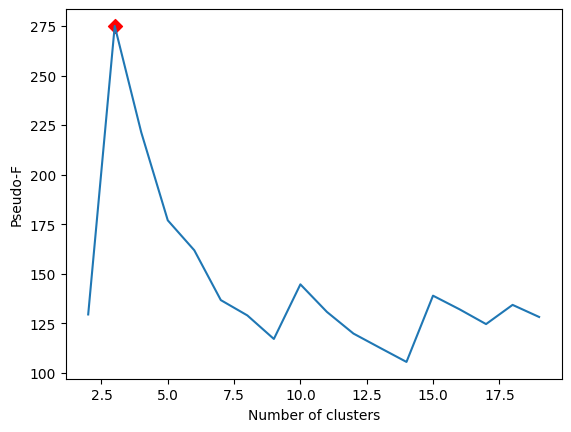

In [140]:
# Отберите число наиболее значимых переменных из вашего варианта с помощью метода
# VarClus. Запустите функцию из шага 8. Как изменилось число кластеров, проекции и лучшие
# представители. Как считаете, субъективное качество кластеризации изменилось? Как и
# почему?
# my count 5 

X_corr = df_baseball_.corr().to_numpy()
X_distance = 1 - np.abs(X_corr)
clusters_vc = AgglomerativeClustering_(X_distance, n_clusters=5, metric='precomputed', linkage='average')
labels = clusters_vc.labels_

# Вычисление центров кластеров вручную, так как наша функция не подходит
centers = []
for cluster_id in range(5):
    # Находим индексы объектов в текущем кластере
    members = np.where(labels == cluster_id)[0]
    
    cluster_points = X_scale[members]
    
    # Вычисляем центроид (мат.ожидание)
    centroid = cluster_points.mean(axis=0)
    centers.append(centroid)

centers = np.array(centers)

prototype_vc = prototype_(centers, X_distance)

best_idx = []
for cluster_id in range(5):
    members = np.where(labels == cluster_id)[0]
    # Расстояния от каждого признака в кластере до центроида
    distances = [np.linalg.norm(X_scale[m] - centers[cluster_id]) for m in members]
    # Индекс признака с минимальным расстоянием
    best_idx.append(members[np.argmin(distances)])

df_new_ = df_baseball_.iloc[:, best_idx]
# print(df_new_)
k_vc = choose_num_clusters(df_new_.to_numpy())
print(f'Наиболее значимые признаки = {df_new_.columns.values}')
print(f'Наиболее подходящее количество кластеров для задачи = {k_vc}')

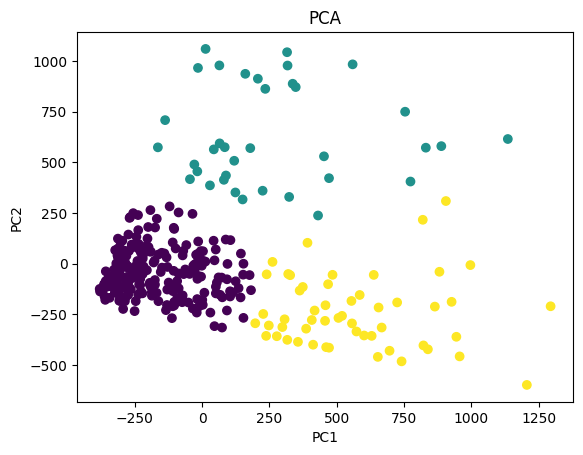

In [139]:
kmeans_clusters_new_vc = KMeans_(df_new_.to_numpy(), n_clusters=k_vc)

features_new_vc = PCA_(df_new_.to_numpy())
plt.scatter(features_new_vc[:,0], features_new_vc[:,1], c=kmeans_clusters_new_vc.labels_)
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [51]:
#«Творческое задание» на поиск аномалий. Загрузите файл mnist_small.csv. Данный набор
# данных содержит подмножество эталонного набора данных рукописных цифр MNIST. 5923
# картинок 28x28 пикселей с изображением нуля и 76 картинок с изображением шестерки.
# Задача состоит в том, чтобы с использованием методов обучения без учителя для своего
# варианта построить одноклассовую модель на основе поиска аномалий, которая максимально
# хорошо отфильтрует шестерки (как аномалии) от нулей (как основной выборки). Признаки
# картинок описываются их координатами (в названии переменных, например «10x12») и
# значением яркости точки по этим координатам. Подбирая параметры метода и преобразуя
# признаки как посчитаете нужным, но не используя при этом информацию о label, постройте
# модель выявления аномалий с EER (Equal Error Rate) меньше 0.2.

# LOF Локальный фактор выбросов,первым шагом вычисления расстояние для каждой точки через метрику
# затем, сортируем asc по расстояниям и выбираем крайнего соседа k-ого, расстояние до этого соседа и будет k_distance(выбранной точки)
# далее считаем расстояние досигаемости (reachability(A,B)) = max(dist(выбранная точка(A), соседи(B)), k_distance(B))
# после, считаем LRD плотность локальной досигаемости, как LRD(A) = k/sum(reachability(A,*)), где * - множество соседей
# ну и последний шаг вычисляем сам LOF(A) = mean(LRD(*)) / LRD(A), данные значения и есть наш последующий scores.

from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

df_mnist = pd.read_csv('mnist_small.csv')
label_ = df_mnist['label'].values
df_mnist = df_mnist.drop(columns=['label'])

X_ = X_to_numpy = df_mnist.to_numpy()

X_ = StandardScaler().fit_transform(X_)

X_ = PCA(n_components=0.90).fit_transform(X_)

lof = LocalOutlierFactor(n_neighbors = 777,contamination=0.015,metric='manhattan') #contamination=0.015, приблизительное ожидание аномалий.
pred = lof.fit_predict(X_)                 # -1 = аномалия, 1 = норма
scores = lof.negative_outlier_factor_    # Локальный фактор выбросов, значения каждого наблюдения сильно отличающегося от -1, и есть аномалии.

# EER - метрика, для оценки качества модели распознования, EER - это порог где fp=fn(приблизтельно равны), в нашем случак 20% ошибок не более допускается
# главные ошибки fp - false positive , ложная тревога, когда это 0, а модель думает что аномалия и fnegative - ложная не тревога, 
# попалась аномалия, но мы не реагируем
# tp - true positive все верно
y_true = (label_ == 6).astype(int)

# рог-кривая сортирует массив scores по убыванию, и добавляет в начало +inf, это будут наши пороги, по ним будем делать далее:
# для каждого порога последовательно считаем TP = TP / (TP + FN) и FP = FP / (FP + TN)
# полученные точки (TP,FP) отмечаем на графике.

fp, tp, _ = metrics.roc_curve(y_true, -scores)
eer_idx = np.nanargmin(np.abs(fp - (1 - tp)))
eer = fp[eer_idx]


print(f'EER = {eer}')
# print(np.where(pred == -1))

EER = 0.07681917946986325


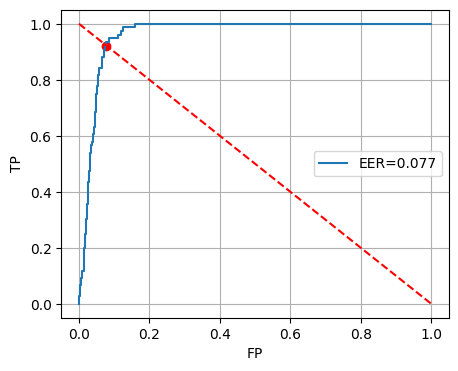

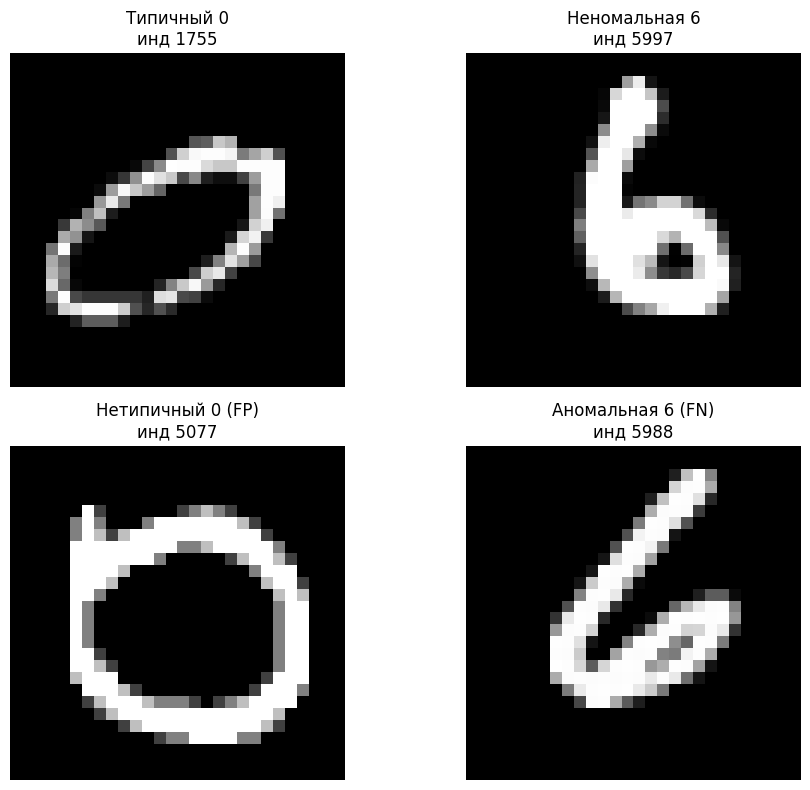

In [52]:
plt.figure(figsize=(5,4))
plt.plot(fp, tp, label=f'EER={eer:.3f}')
plt.plot([0,1],[1,0],'r--')
plt.scatter(fp[eer_idx], tp[eer_idx], c='r')
plt.xlabel('FP'); plt.ylabel('TP'); plt.legend(); plt.grid()
plt.show()

# поиск четырёх изображений
tn = np.where((y_true == 0) & (pred == 1))[0]      # верные нули
tp = np.where((y_true == 1) & (pred == -1))[0]     # верные шестёрки
fp = np.where((y_true == 0) & (pred == -1))[0]     # ложные шестерки
fn = np.where((y_true == 1) & (pred == 1))[0]      # пропущенные аномалии

best0 = tn[np.argmin(scores[tn])]             # самый типичный 0
best6 = tp[np.argmax(scores[tp])]             # самая неаномальная 6
worst0 = fp[np.argmax(scores[fp])]            # самый нетипичный 0
worst6 = fn[np.argmin(scores[fn])]            # самая аномальная 6

# отображение
def plot_digit(idx, title):
    plt.imshow(X_to_numpy[idx].reshape(28,28), cmap='gray')
    plt.title(title); plt.axis('off')

plt.figure(figsize=(10,8))
plt.subplot(2,2,1); plot_digit(best0, f'Типичный 0\nинд {best0}')
plt.subplot(2,2,2); plot_digit(best6, f'Неномальная 6\nинд {best6}')
plt.subplot(2,2,3); plot_digit(worst0, f'Нетипичный 0 (FP)\nинд {worst0}')
plt.subplot(2,2,4); plot_digit(worst6, f'Аномальная 6 (FN)\nинд {worst6}')
plt.tight_layout()
plt.show()